In [2]:
!pip install polars


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install pyarrow


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def read_parquet_by_type(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
    purchase_history_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
    item_chunk_files = [file for file in files if 'item_chunk' in file]
    
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
    purchase_history_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_history_chunk_files]) if purchase_history_chunk_files else None
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
    
    # Trả về một dictionary chứa các DataFrame
    return {
        "user_chunk": user_chunk_df,
        "purchase_history_chunk": purchase_history_chunk_df,
        "item_chunk": item_chunk_df
    }

In [3]:
train_path = 'E:/KHMT2023_CS_UIT/05_C_Python_For_ML/recommendation_dataset'
dataframes = read_parquet_by_type(train_path)

df_user = dataframes["user_chunk"]
df_purchase = dataframes["purchase_history_chunk"]
df_item = dataframes["item_chunk"]

In [10]:
df_purchase.schema

Schema([('timestamp', Int64),
        ('user_id', String),
        ('item_id', String),
        ('event_type', String),
        ('event_value', Decimal(precision=38, scale=4)),
        ('price', Decimal(precision=38, scale=4)),
        ('date_key', Int32),
        ('quantity', Int32),
        ('customer_id', Int32),
        ('created_date', Datetime(time_unit='us', time_zone=None)),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('channel', String),
        ('payment', String),
        ('location', Int32),
        ('discount', Decimal(precision=38, scale=4)),
        ('is_deleted', Boolean)])

# EDA function

## IMPORTS & CẤU HÌNH

In [11]:
# ================================
# 0. IMPORTS & CẤU HÌNH
# ================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")


## HELPER: TÍNH CRAMÉR'S V

In [12]:
# ================================
# HELPER: TÍNH CRAMÉR'S V
# ================================
def cramers_v_for_two_series(x: pd.Series, y: pd.Series) -> float:
    """
    Tính Cramér's V giữa hai biến category (x, y).
    Không dùng SciPy, tự tính chi-square.
    """
    # Bỏ NA
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if x.empty or y.empty:
        return np.nan

    # Bảng tần suất
    contingency = pd.crosstab(x, y)
    n = contingency.values.sum()
    if n == 0:
        return np.nan

    # Chi-square
    row_sums = contingency.sum(axis=1).values.reshape(-1, 1)
    col_sums = contingency.sum(axis=0).values.reshape(1, -1)
    expected = row_sums * col_sums / n
    # tránh chia 0
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = ((contingency.values - expected) ** 2 / expected)
        chi2 = np.nansum(chi2)

    phi2 = chi2 / n
    r, c = contingency.shape
    k = min(r - 1, c - 1)
    if k <= 0:
        return np.nan

    return float(np.sqrt(phi2 / k))

## HÀM PHÂN LOẠI KIỂU DỮ LIỆU (THEO SCHEMA POLARS)

In [5]:
# ================================
# 1. HÀM PHÂN LOẠI KIỂU DỮ LIỆU (THEO SCHEMA POLARS)
# ================================

NUMERIC_DTYPES = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}

CATEGORICAL_DTYPES = {
    pl.Utf8,   # String
    pl.Boolean
}

DATETIME_DTYPES = {
    pl.Datetime, pl.Date
}


def split_columns_by_dtype(df: pl.DataFrame):
    """
    Tách danh sách cột thành 3 nhóm: numeric, categorical, datetime
    để dùng lại cho các bước EDA.
    """
    numeric_cols = []
    categorical_cols = []
    datetime_cols = []

    for col, dtype in df.schema.items():
        if (dtype in NUMERIC_DTYPES) or isinstance(dtype, pl.Decimal):
            numeric_cols.append(col)
        elif (dtype in CATEGORICAL_DTYPES):
            categorical_cols.append(col)
        elif isinstance(dtype, pl.Datetime) or isinstance(dtype, pl.Date):
            datetime_cols.append(col)
        else:
            # Các kiểu khác (struct, list, ...): tạm coi là categorical
            categorical_cols.append(col)

    return numeric_cols, categorical_cols, datetime_cols

## TASK 1 – PHÂN TÍCH ĐƠN BIẾN

In [6]:
# ================================
# 2. TASK 1 – PHÂN TÍCH ĐƠN BIẾN
# ================================

# 2.1 TÓM TẮT CẤU TRÚC DATAFRAME
def summarize_structure(df: pl.DataFrame, df_name: str = "df"):
    print(f"========== TỔNG QUAN {df_name} ==========")
    print(f"Số dòng: {df.height:,}")
    print(f"Số cột: {df.width}")
    print("\n--- Schema ---")
    print(df.schema)

    # Tỷ lệ null từng cột
    print("\n--- Tỷ lệ NULL từng cột ---")
    null_counts = df.null_count()
    null_counts_melt = null_counts.melt(variable_name="column", value_name="null_count")
    null_counts_melt = null_counts_melt.with_columns(
        (pl.col("null_count") / df.height).alias("null_ratio")
    ).sort("null_ratio", descending=True)
    print(null_counts_melt)

    # Số lượng giá trị unique
    print("\n--- Số lượng giá trị duy nhất (nunique) ---")
    nunique_df = df.select([pl.col(c).n_unique().alias(c) for c in df.columns])
    nunique_melt = nunique_df.melt(variable_name="column", value_name="nunique") \
                             .sort("nunique", descending=True)
    print(nunique_melt)

    return null_counts_melt, nunique_melt

### ĐƠN BIẾN CHO CỘT SỐ (NUMERIC)

In [7]:
# 2.2 ĐƠN BIẾN CHO CỘT SỐ (NUMERIC)
def univariate_numeric(df: pl.DataFrame, numeric_cols: list, df_name: str = "df"):
    print(f"\n========== ĐƠN BIẾN: NUMERIC ({df_name}) ==========")
    if not numeric_cols:
        print("Không có cột numeric.")
        return

    # Bảng describe tổng quan
    desc = df.select([pl.col(c) for c in numeric_cols]).describe()
    print(desc)

    # Vẽ histogram + boxplot cho từng cột numeric
    for col in numeric_cols:
        series = df[col].drop_nulls().to_pandas()

        # 🔥 FIX: Convert mọi giá trị Decimal → float
        try:
            series = series.astype(float)
        except:
            series = series.apply(lambda x: float(x))

        if series.empty:
            print(f"[{col}] toàn null, bỏ qua plot.")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"Numeric EDA – {col}", fontsize=14)

        # Histogram
        axes[0].hist(series, bins=30)
        axes[0].set_title(f"Histogram – {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Count")

        # Boxplot
        axes[1].boxplot(series, vert=True)
        axes[1].set_title(f"Boxplot – {col}")
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()


### ĐƠN BIẾN CHO CỘT CATEGORY (STRING/BOOLEAN)

In [8]:
# 2.3 ĐƠN BIẾN CHO CỘT CATEGORY (STRING/BOOLEAN)
def univariate_categorical(df: pl.DataFrame, categorical_cols: list,
                           df_name: str = "df", top_k: int = 10):
    print(f"\n========== ĐƠN BIẾN: CATEGORICAL ({df_name}) ==========")
    if not categorical_cols:
        print("Không có cột categorical.")
        return

    for col in categorical_cols:
        print(f"\n--- Cột: {col} ---")
        vc = df[col].value_counts().sort("count", descending=True)
        print(f"Top {top_k} giá trị phổ biến:")
        print(vc.head(top_k))

        # Plot bar top_k
        vc_top = vc.head(top_k)
        # Đưa sang pandas cho dễ plot
        vc_pd = vc_top.to_pandas()
        plt.figure(figsize=(8, 4))
        sns.barplot(x="count", y=col, data=vc_pd)
        plt.title(f"Value Counts (Top {top_k}) – {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

### ĐƠN BIẾN CHO CỘT DATETIME

In [9]:
# 2.4 ĐƠN BIẾN CHO CỘT DATETIME
def univariate_datetime(df: pl.DataFrame, datetime_cols: list, df_name: str = "df"):
    print(f"\n========== ĐƠN BIẾN: DATETIME ({df_name}) ==========")
    if not datetime_cols:
        print("Không có cột datetime.")
        return

    for col in datetime_cols:
        print(f"\n--- Cột datetime: {col} ---")
        non_null = df[col].drop_nulls()
        if non_null.is_empty():
            print(f"[{col}] toàn null.")
            continue

        min_ts = non_null.min()
        max_ts = non_null.max()
        print(f"Min: {min_ts} | Max: {max_ts}")

        # Nếu muốn vẽ số lượng bản ghi theo thời gian (theo tháng)
        # Chuyển sang pandas để dễ resample (hoặc xử lý bằng Polars native đều được)
        s_pd = non_null.to_pandas()
        s_pd = s_pd.sort_values()
        # Nếu là Datetime -> series
        s_pd.index = s_pd
        cnt_by_month = s_pd.resample("M").size()

        plt.figure(figsize=(10, 4))
        cnt_by_month.plot()
        plt.title(f"Số bản ghi theo tháng – {col}")
        plt.xlabel("Thời gian (month)")
        plt.ylabel("Số bản ghi")
        plt.tight_layout()
        plt.show()

## TASK 2 – PHÂN TÍCH HAI BIẾN

### NUMERIC – NUMERIC: CORRELATION

In [10]:
# ================================
# 3. TASK 2 – PHÂN TÍCH HAI BIẾN
# ================================

# 3.1 NUMERIC – NUMERIC: CORRELATION
def bivariate_numeric_numeric(df: pl.DataFrame, numeric_cols: list, df_name: str = "df"):
    print(f"\n========== HAI BIẾN: NUMERIC – NUMERIC ({df_name}) ==========")
    if len(numeric_cols) < 2:
        print("Số cột numeric < 2, không vẽ ma trận tương quan.")
        return

    df_num_pd = df.select(numeric_cols).to_pandas()
    corr = df_num_pd.corr()

    print("\n--- Ma trận tương quan ---")
    print(corr)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="RdBu_r")
    plt.title(f"Correlation Matrix – {df_name}")
    plt.tight_layout()
    plt.show()

### NUMERIC – CATEGORY: BOXPlot theo nhóm

In [11]:
# 3.2 NUMERIC – CATEGORY: BOXPlot theo nhóm
def bivariate_numeric_categorical(df: pl.DataFrame,
                                  numeric_cols: list,
                                  categorical_cols: list,
                                  df_name: str = "df",
                                  max_cat_cardinality: int = 15):
    print(f"\n========== HAI BIẾN: NUMERIC – CATEGORICAL ({df_name}) ==========")
    if not numeric_cols or not categorical_cols:
        print("Thiếu numeric hoặc categorical, bỏ qua.")
        return

    # Chỉ dùng những categorical có số lượng unique không quá lớn
    nunique = df.select([pl.col(c).n_unique().alias(c) for c in categorical_cols])
    nunique_melt = nunique.melt(variable_name="column", value_name="nunique")
    valid_cats = (
        nunique_melt
        .filter(pl.col("nunique") <= max_cat_cardinality)
        .get_column("column")
        .to_list()
    )

    if not valid_cats:
        print(f"Không có categorical nào có cardinality ≤ {max_cat_cardinality}.")
        return

    # Vẽ boxplot cho từng cặp numeric – categorical (có thể giới hạn vài cột chính)
    for num_col in numeric_cols:
        for cat_col in valid_cats:
            print(f"\nBoxplot: {num_col} theo {cat_col}")
            # Lấy dữ liệu cần thiết
            sub_df = df.select([cat_col, num_col]).drop_nulls()
            if sub_df.is_empty():
                print("Bộ dữ liệu con rỗng sau khi drop null, bỏ qua.")
                continue

            sub_pd = sub_df.to_pandas()
            plt.figure(figsize=(8, 4))
            sns.boxplot(x=cat_col, y=num_col, data=sub_pd)
            plt.title(f"{num_col} by {cat_col}")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

### 3.3 CATEGORY – CATEGORY: CROSSTAB

In [12]:
# 3.3 CATEGORY – CATEGORY: CROSSTAB
def bivariate_categorical_categorical(df: pl.DataFrame,
                                      categorical_cols: list,
                                      df_name: str = "df",
                                      max_cat_cardinality: int = 50,
                                      high_similarity_threshold: float = 0.8):
    """
    - Lọc các cột category có cardinality không quá lớn.
    - Tính ma trận Cramér's V giữa các cột đó.
    - Vẽ heatmap (đỏ = tương đồng cao, xanh = thấp).
    - Gợi ý các cặp cột nên xem xét loại bỏ bớt (V > threshold).
    """
    print(f"\n========== HAI BIẾN: CATEGORY – CATEGORY (Cramér's V) ({df_name}) ==========")
    if len(categorical_cols) < 2:
        print("Số cột categorical < 2, bỏ qua.")
        return

    # 1. Chọn các cột category có số unique vừa phải (tránh ID/text dài)
    # nunique = df.select([pl.col(c).n_unique().alias(c) for c in categorical_cols])
    # nunique_melt = nunique.melt(variable_name="column", value_name="nunique")
    # valid_cats = (
    #     nunique_melt
    #     .filter((pl.col("nunique") >= 2) & (pl.col("nunique") <= max_cat_cardinality))
    #     .get_column("column")
    #     .to_list()
    # )

    valid_cats = categorical_cols.copy()

    print(f"Các cột categorical dùng để tính Cramér's V (2 ≤ nunique ≤ {max_cat_cardinality}):")
    print(valid_cats)

    if len(valid_cats) < 2:
        print("Không đủ cột categorical phù hợp để tính Cramér's V.")
        return

    # 2. Lấy dữ liệu sang pandas cho tiện xử lý
    df_cat_pd = df.select(valid_cats).to_pandas()

    # 3. Khởi tạo ma trận Cramér's V
    k = len(valid_cats)
    v_matrix = pd.DataFrame(
        data=np.zeros((k, k), dtype=float),
        index=valid_cats,
        columns=valid_cats,
    )

    # 4. Tính Cramér's V cho từng cặp
    for i in range(k):
        for j in range(i, k):
            col1 = valid_cats[i]
            col2 = valid_cats[j]
            if i == j:
                v_matrix.loc[col1, col2] = 0.0  # đường chéo = 0 (không xét tự tương quan)
            else:
                v = cramers_v_for_two_series(df_cat_pd[col1], df_cat_pd[col2])
                v_matrix.loc[col1, col2] = v
                v_matrix.loc[col2, col1] = v

    print("\n--- Ma trận Cramér's V ---")
    print(v_matrix)

    # 5. Vẽ heatmap (đỏ = tương đồng cao, xanh = thấp)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        v_matrix,
        annot=True,
        fmt=".3f",
        vmin=0, vmax=1,
        cmap="RdBu_r"  # xanh giá trị nhỏ, đỏ giá trị lớn
    )
    plt.title("Cramér's V Heatmap")
    plt.xlabel("Cột")
    plt.ylabel("Cột")
    plt.tight_layout()
    plt.show()

    # 6. Gợi ý các cặp cột rất giống nhau (V lớn)
    print(f"\n--- Các cặp cột có Cramér's V ≥ {high_similarity_threshold} (rất tương đồng) ---")
    similar_pairs = []
    for i in range(k):
        for j in range(i + 1, k):
            v = v_matrix.iloc[i, j]
            if v >= high_similarity_threshold:
                col1 = v_matrix.index[i]
                col2 = v_matrix.columns[j]
                similar_pairs.append((col1, col2, v))

    if not similar_pairs:
        print("Không có cặp nào vượt ngưỡng.")
    else:
        for col1, col2, v in sorted(similar_pairs, key=lambda x: -x[2]):
            print(f"{col1} – {col2}: Cramér's V = {v:.3f}")
        print("\n=> Với mỗi cặp trên, bạn có thể giữ lại 1 trường (cột) và loại bớt 1 trường còn lại để tránh trùng thông tin.")


## TASK 3 – GỢI Ý TIỀN XỬ LÝ

In [13]:
# ================================
# 4. TASK 3 – GỢI Ý TIỀN XỬ LÝ
# ================================

def preprocessing_suggestions(
    df: pl.DataFrame,
    null_counts_melt: pl.DataFrame,
    nunique_melt: pl.DataFrame,
    df_name: str = "df",
    high_null_thresh: float = 0.5,
    high_cardinality_thresh: int = 50
):
    """
    Tạo các gợi ý sơ bộ cho bước tiền xử lý:
    - Cột nhiều NULL
    - Cột ít thông tin (constant/near-constant)
    - Cột có cardinality quá cao (ID, text free-form,…)
    """
    print(f"\n========== GỢI Ý TIỀN XỬ LÝ ({df_name}) ==========")

    # 4.1. Cột có tỷ lệ NULL cao
    high_null_cols = (
        null_counts_melt
        .filter(pl.col("null_ratio") >= high_null_thresh)
    )
    print(f"\n--- Cột có NULL >= {high_null_thresh*100:.0f}% ---")
    print(high_null_cols)

    # 4.2. Cột cardinality rất thấp (có thể là constant)
    low_card_cols = nunique_melt.filter(pl.col("nunique") <= 1)
    print("\n--- Cột có nunique <= 1 (constant hoặc rỗng) ---")
    print(low_card_cols)

    # 4.3. Cột cardinality rất cao (ID, text)
    high_card_cols = nunique_melt.filter(pl.col("nunique") >= high_cardinality_thresh)
    print(f"\n--- Cột có nunique >= {high_cardinality_thresh} (ID hoặc text free-form) ---")
    print(high_card_cols)

    # 4.4. Nhóm cột hệ thống (gợi ý cứng cho dataset này)
    system_like_cols = [c for c in df.columns
                        if "created_date" in c
                        or "updated_date" in c
                        or "sync_status" in c
                        or "sync_error" in c
                        or "last_sync_date" in c
                        or "is_deleted" in c]
    print("\n--- Gợi ý: các cột hệ thống có thể xem xét loại bỏ / tách riêng ---")
    print(system_like_cols)

    print("\n==> Dựa trên các bảng trên, bạn viết phần nhận xét cho báo cáo:")
    print("- Cột nào nên loại bỏ vì quá nhiều NULL / constant / hệ thống.")
    print("- Cột nào cần xử lý NULL (tỷ lệ NULL trung bình, không quá cao).")
    print("- Cột nào có cardinality cao nên encoding đặc biệt, hoặc chỉ dùng để join (ID).")

## PIPELINE EDA CHO df_purchase

In [4]:
df_purchase_sample = df_purchase.sample(n=50000, with_replacement=False)


In [14]:
# ================================
# 5. PIPELINE EDA CHO df_purchase_sample
# ================================

def run_eda_for_user(df_purchase_sample: pl.DataFrame):
    # 5.1. Tổng quan
    null_counts_melt, nunique_melt = summarize_structure(df_purchase_sample, df_name="df_purchase_sample")

    # 5.2. Tách cột theo dtype
    numeric_cols, categorical_cols, datetime_cols = split_columns_by_dtype(df_purchase_sample)
    print("\n--- Nhóm cột theo dtype ---")
    print("Numeric cols:", numeric_cols)
    print("Categorical cols:", categorical_cols)
    print("Datetime cols:", datetime_cols)

    # 5.3. Đơn biến
    univariate_numeric(df_purchase_sample, numeric_cols, df_name="df_purchase_sample")
    univariate_categorical(df_purchase_sample, categorical_cols, df_name="df_purchase_sample", top_k=10)
    univariate_datetime(df_purchase_sample, datetime_cols, df_name="df_purchase_sample")

    # 5.4. Hai biến
    bivariate_numeric_numeric(df_purchase_sample, numeric_cols, df_name="df_purchase_sample")
    bivariate_numeric_categorical(df_purchase_sample, numeric_cols, categorical_cols, df_name="df_purchase_sample")
    bivariate_categorical_categorical(df_purchase_sample, categorical_cols, df_name="df_purchase_sample")

    # 5.5. Gợi ý tiền xử lý
    preprocessing_suggestions(
        df_purchase_sample,
        null_counts_melt=null_counts_melt,
        nunique_melt=nunique_melt,
        df_name="df_purchase_sample"
    )

##  CÁCH GỌI CHO df_item

========== TỔNG QUAN df_purchase_sample ==========
Số dòng: 50,000
Số cột: 16

--- Schema ---
Schema([('timestamp', Int64), ('user_id', String), ('item_id', String), ('event_type', String), ('event_value', Decimal(precision=38, scale=4)), ('price', Decimal(precision=38, scale=4)), ('date_key', Int32), ('quantity', Int32), ('customer_id', Int32), ('created_date', Datetime(time_unit='us', time_zone=None)), ('updated_date', Datetime(time_unit='us', time_zone=None)), ('channel', String), ('payment', String), ('location', Int32), ('discount', Decimal(precision=38, scale=4)), ('is_deleted', Boolean)])

--- Tỷ lệ NULL từng cột ---
shape: (16, 3)
┌─────────────┬────────────┬────────────┐
│ column      ┆ null_count ┆ null_ratio │
│ ---         ┆ ---        ┆ ---        │
│ str         ┆ u32        ┆ f64        │
╞═════════════╪════════════╪════════════╡
│ timestamp   ┆ 0          ┆ 0.0        │
│ user_id     ┆ 0          ┆ 0.0        │
│ item_id     ┆ 0          ┆ 0.0        │
│ event_type  ┆ 0

C:\Users\huynh\AppData\Local\Temp\ipykernel_13812\1638551028.py:16: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  null_counts_melt = null_counts.melt(variable_name="column", value_name="null_count")
C:\Users\huynh\AppData\Local\Temp\ipykernel_13812\1638551028.py:25: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  nunique_melt = nunique_df.melt(variable_name="column", value_name="nunique") \


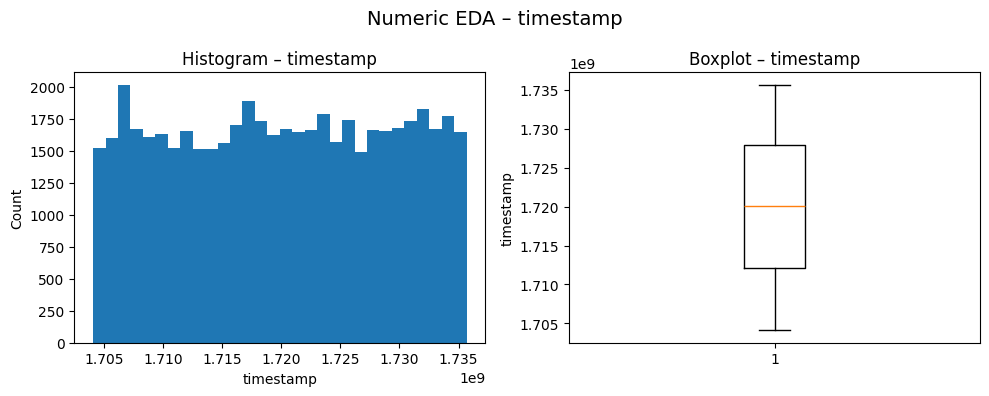

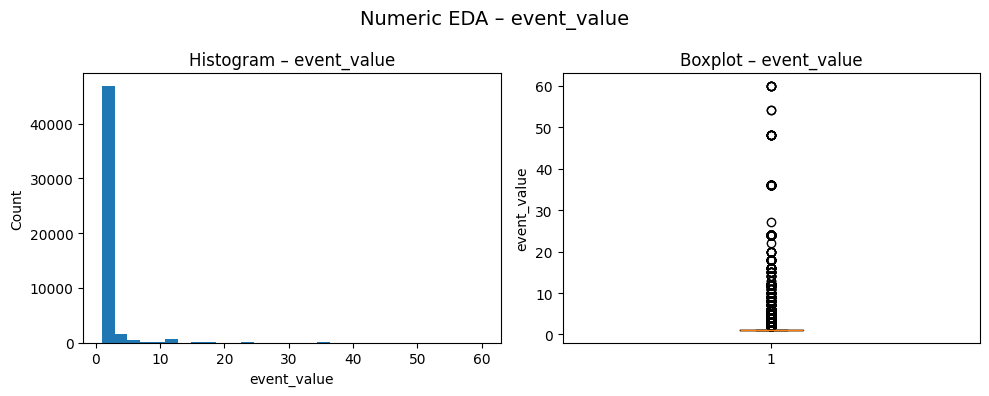

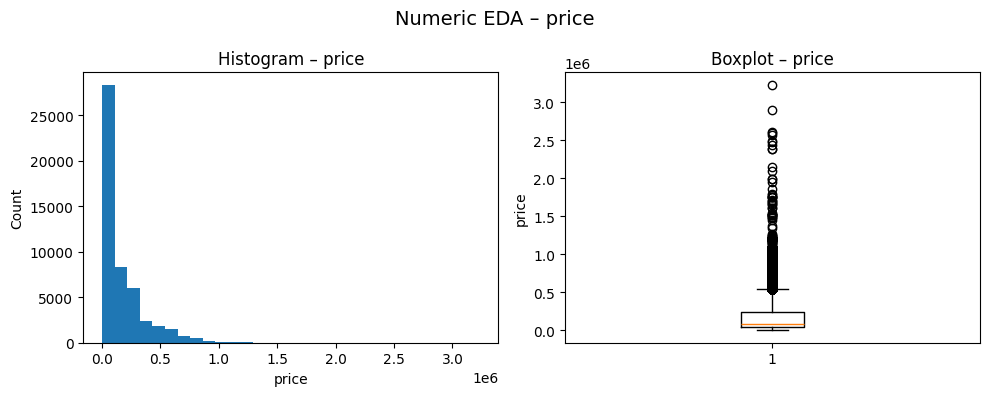

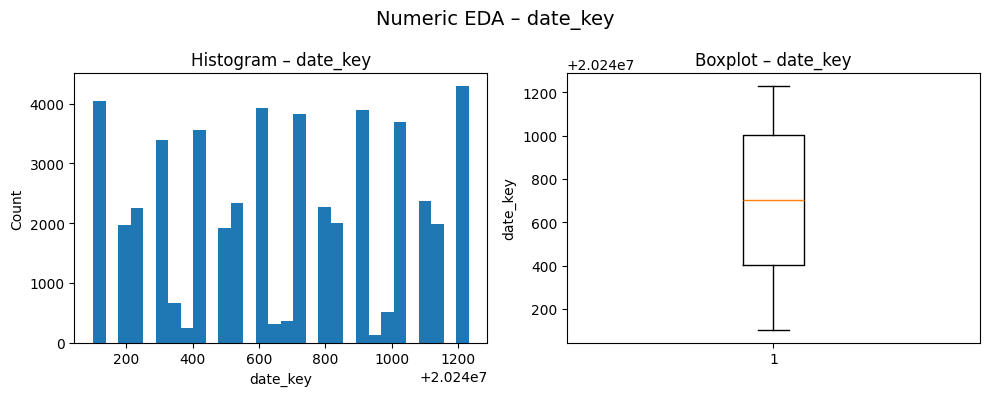

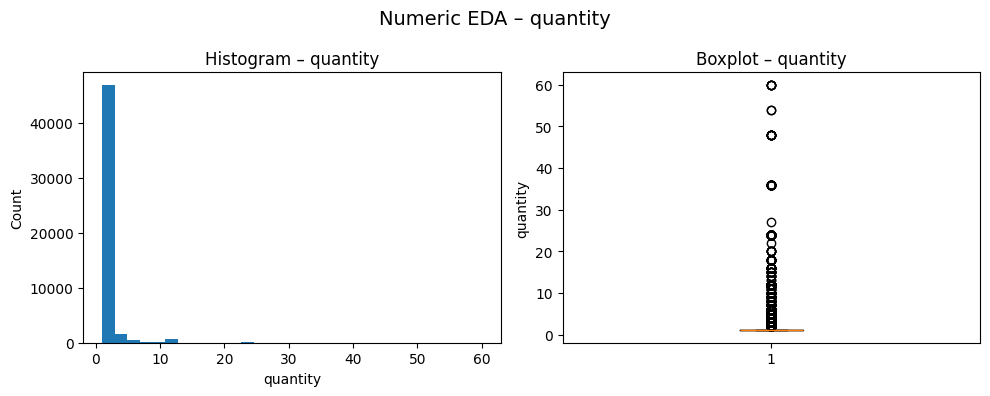

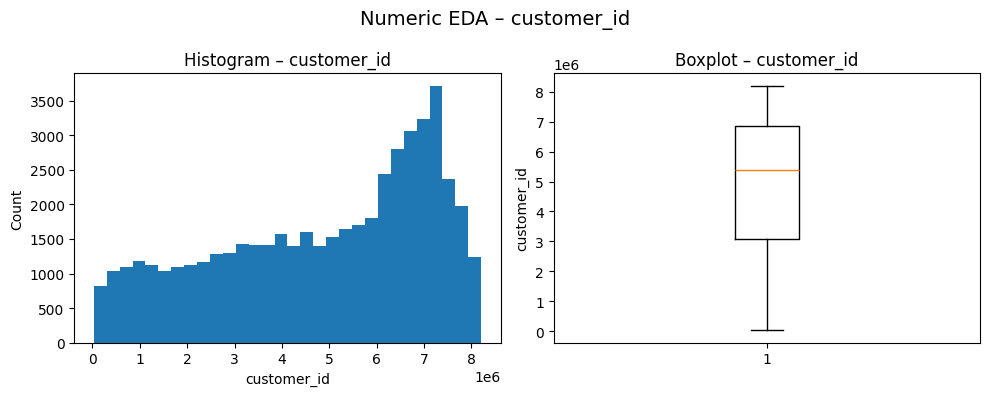

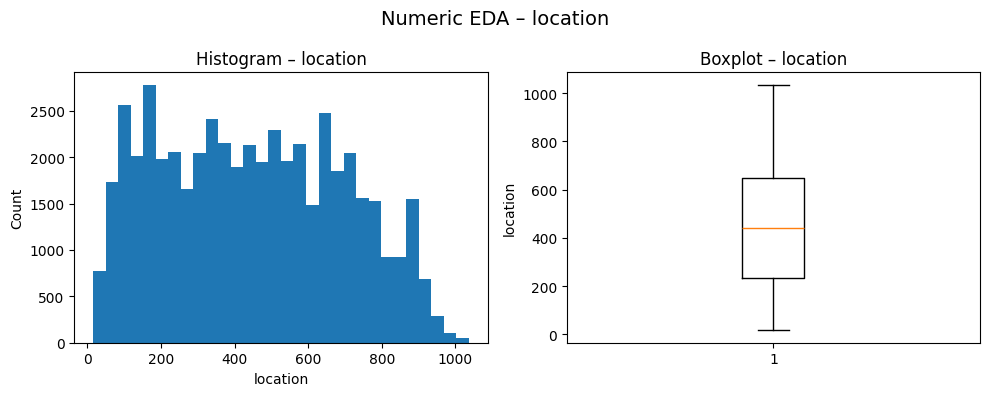

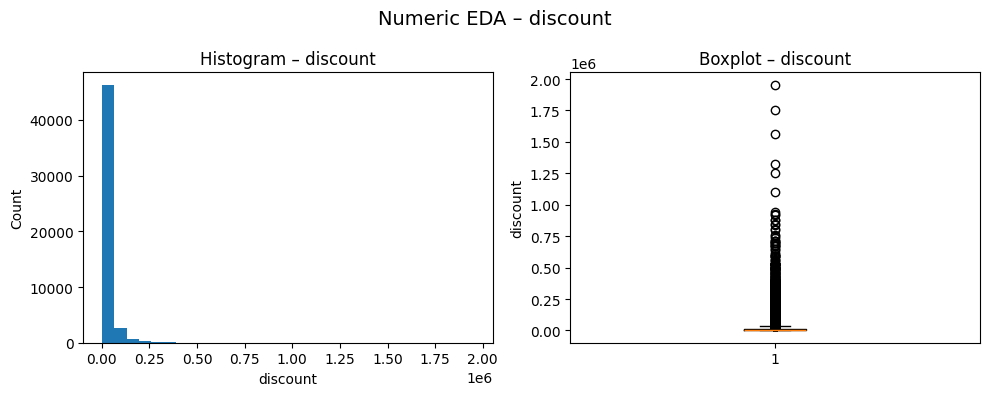


========== ĐƠN BIẾN: CATEGORICAL (df_purchase_sample) ==========

--- Cột: user_id ---
Top 10 giá trị phổ biến:
shape: (10, 2)
┌─────────────────────────────────┬───────┐
│ user_id                         ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ 2232e24eef7e8dd1b4d54bec2b7e70… ┆ 4     │
│ c89db5923335893451ee1e16e34806… ┆ 4     │
│ 93444c01cbe5eb3746222f60be6a3f… ┆ 4     │
│ 62ed6c559cc8c45ed4af416aecbf15… ┆ 4     │
│ 8934f331a7470323e84cedfc270ae6… ┆ 4     │
│ 58c982ef42e43453d8de280ae364b0… ┆ 4     │
│ f1efb83727951cd074793aecc67425… ┆ 4     │
│ e4121c7fee4447506609d49f6e8387… ┆ 4     │
│ 93f317842ad7347614056191b50307… ┆ 4     │
│ a397ba885dbecb3aa25bd1a86b73c7… ┆ 4     │
└─────────────────────────────────┴───────┘


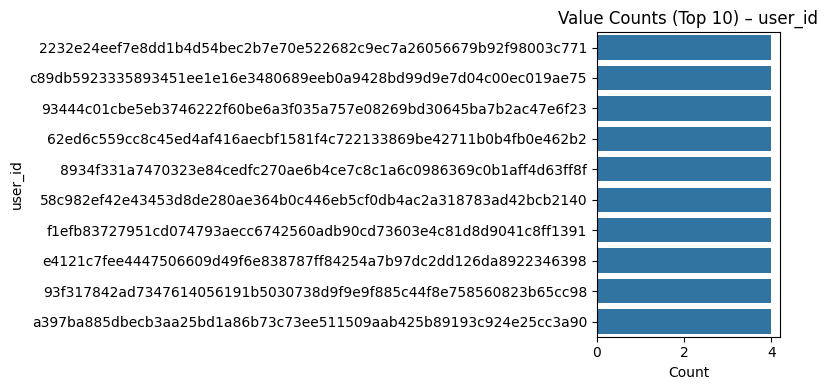


--- Cột: item_id ---
Top 10 giá trị phổ biến:
shape: (10, 2)
┌───────────────┬───────┐
│ item_id       ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ 1512000000004 ┆ 432   │
│ 2803000000013 ┆ 340   │
│ 4690000000001 ┆ 291   │
│ 0020010000438 ┆ 267   │
│ 5950000000001 ┆ 262   │
│ 2803000000011 ┆ 224   │
│ 0029130000030 ┆ 222   │
│ 2803000000012 ┆ 222   │
│ 3773000000004 ┆ 218   │
│ 0020010000440 ┆ 217   │
└───────────────┴───────┘


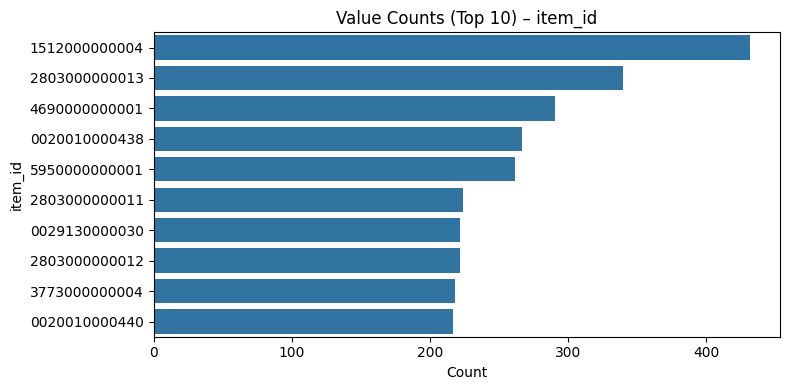


--- Cột: event_type ---
Top 10 giá trị phổ biến:
shape: (1, 2)
┌────────────┬───────┐
│ event_type ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Purchase   ┆ 50000 │
└────────────┴───────┘


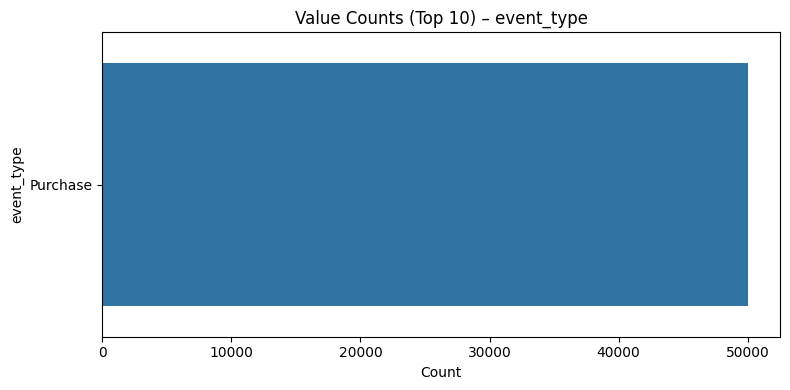


--- Cột: channel ---
Top 10 giá trị phổ biến:
shape: (8, 2)
┌─────────────┬───────┐
│ channel     ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ In-Store    ┆ 46176 │
│ iOS         ┆ 1916  │
│ SPE         ┆ 877   │
│ Android     ┆ 689   │
│ Web         ┆ 217   │
│ Call        ┆ 85    │
│ CRM Partner ┆ 35    │
│ Chat        ┆ 5     │
└─────────────┴───────┘


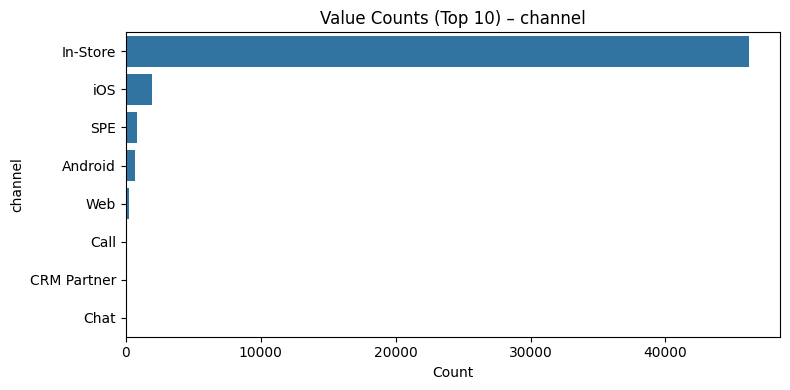


--- Cột: payment ---
Top 10 giá trị phổ biến:
shape: (9, 2)
┌────────────────┬───────┐
│ payment        ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Tiền mặt       ┆ 31316 │
│ VietQR         ┆ 8220  │
│ Cà thẻ         ┆ 5587  │
│ VNPay          ┆ 2904  │
│ MoMo           ┆ 1068  │
│ Không xác định ┆ 494   │
│ ZaloPay        ┆ 335   │
│ ShopeePay      ┆ 54    │
│ Kredivo        ┆ 22    │
└────────────────┴───────┘


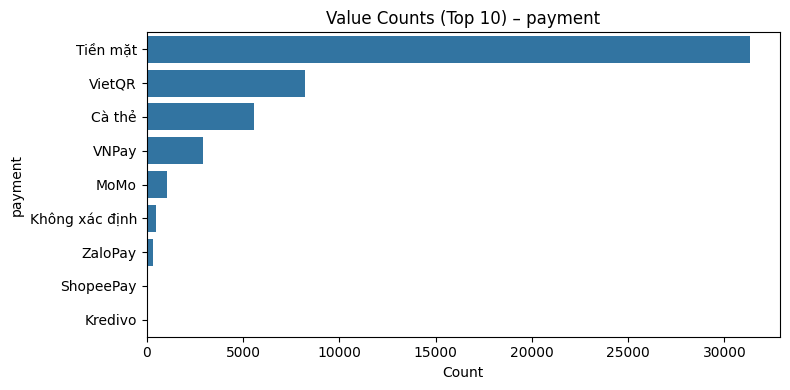


--- Cột: is_deleted ---
Top 10 giá trị phổ biến:
shape: (1, 2)
┌────────────┬───────┐
│ is_deleted ┆ count │
│ ---        ┆ ---   │
│ bool       ┆ u32   │
╞════════════╪═══════╡
│ false      ┆ 50000 │
└────────────┴───────┘


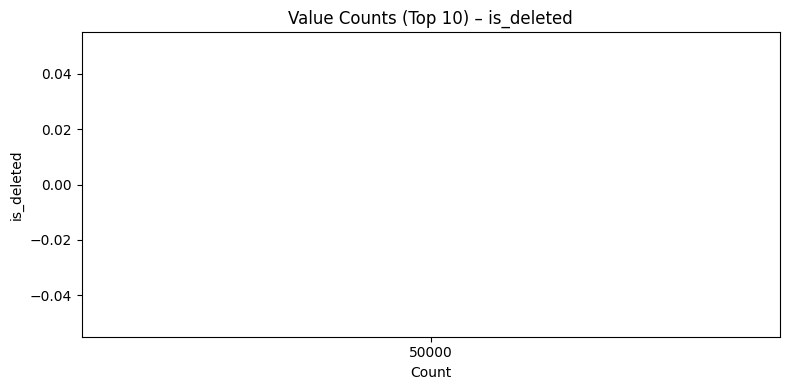


========== ĐƠN BIẾN: DATETIME (df_purchase_sample) ==========

--- Cột datetime: created_date ---
Min: 2024-01-01 07:54:09.640000 | Max: 2024-12-31 22:04:04.833000


C:\Users\huynh\AppData\Local\Temp\ipykernel_13812\2475300363.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cnt_by_month = s_pd.resample("M").size()


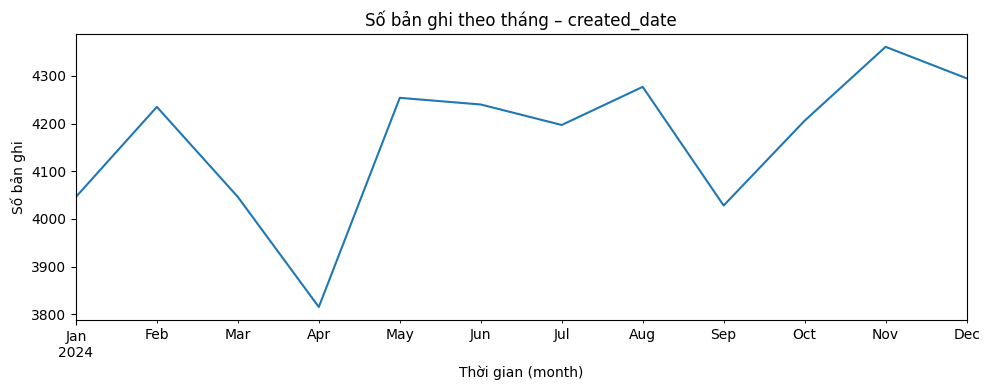


--- Cột datetime: updated_date ---
Min: 2024-01-01 07:54:09.640000 | Max: 2025-02-05 13:18:39.653000


C:\Users\huynh\AppData\Local\Temp\ipykernel_13812\2475300363.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cnt_by_month = s_pd.resample("M").size()


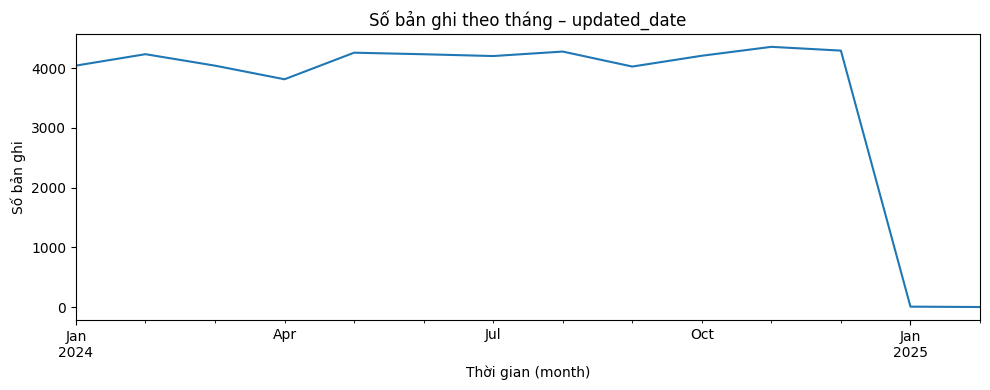


========== HAI BIẾN: NUMERIC – NUMERIC (df_purchase_sample) ==========

--- Ma trận tương quan ---
             timestamp  event_value     price  date_key  quantity  \
timestamp     1.000000     0.009667 -0.007483  0.998291  0.009667   
event_value   0.009667     1.000000 -0.075264  0.009949  1.000000   
price        -0.007483    -0.075264  1.000000 -0.007620 -0.075264   
date_key      0.998291     0.009949 -0.007620  1.000000  0.009949   
quantity      0.009667     1.000000 -0.075264  0.009949  1.000000   
customer_id   0.092792    -0.039296  0.047100  0.092592 -0.039296   
location      0.039613    -0.004425 -0.002579  0.039343 -0.004425   
discount      0.011291     0.161972  0.120478  0.011017  0.161972   

             customer_id  location  discount  
timestamp       0.092792  0.039613  0.011291  
event_value    -0.039296 -0.004425  0.161972  
price           0.047100 -0.002579  0.120478  
date_key        0.092592  0.039343  0.011017  
quantity       -0.039296 -0.004425  0.16197

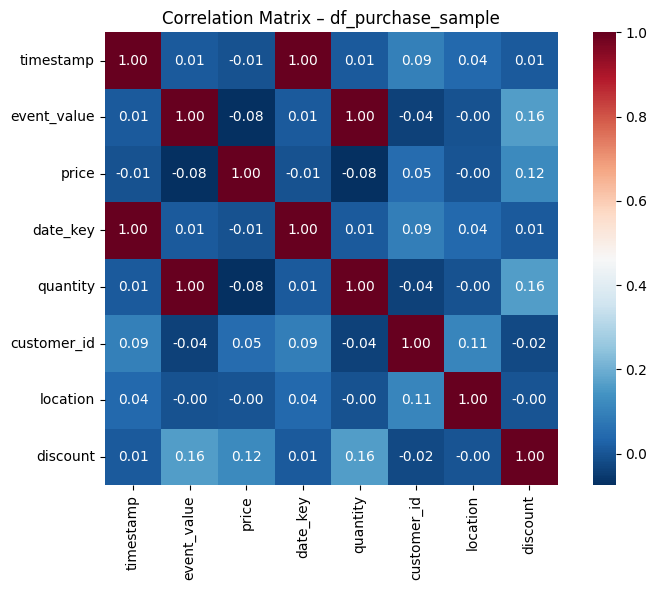


========== HAI BIẾN: NUMERIC – CATEGORICAL (df_purchase_sample) ==========

Boxplot: timestamp theo event_type


C:\Users\huynh\AppData\Local\Temp\ipykernel_13812\722068846.py:14: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  nunique_melt = nunique.melt(variable_name="column", value_name="nunique")


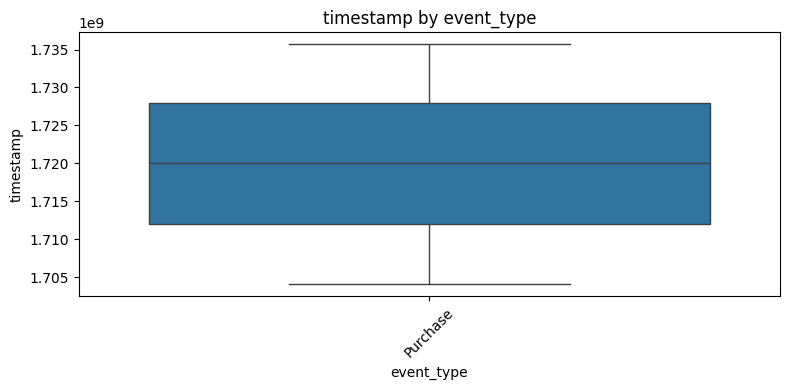


Boxplot: timestamp theo channel


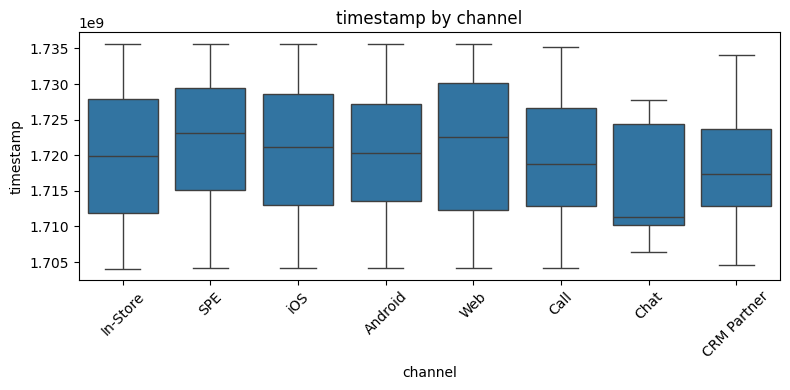


Boxplot: timestamp theo payment


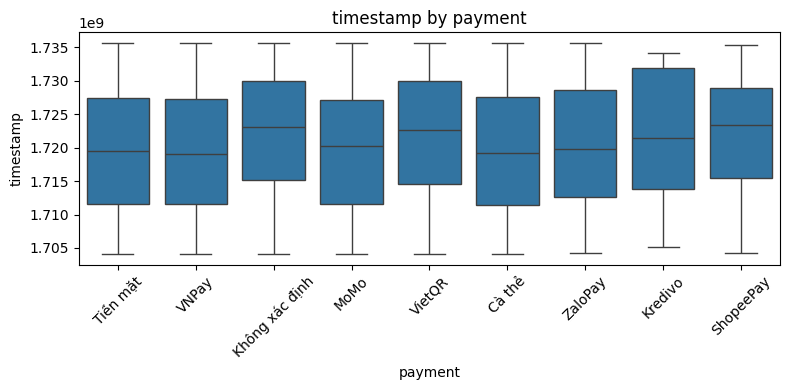


Boxplot: timestamp theo is_deleted


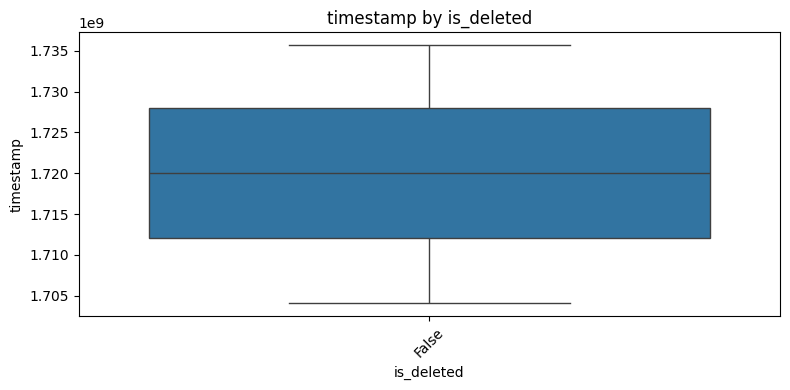


Boxplot: event_value theo event_type


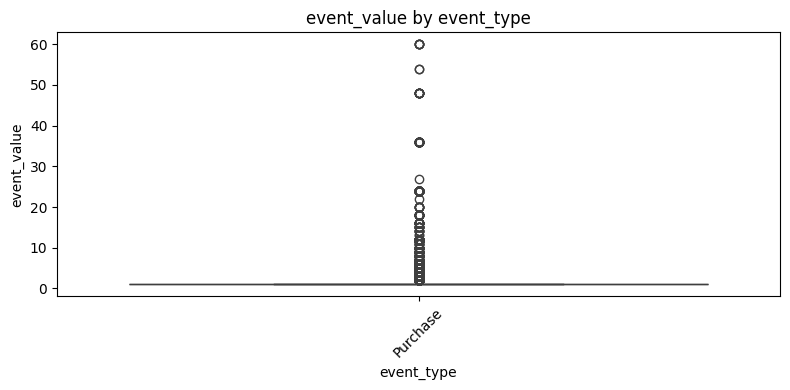


Boxplot: event_value theo channel


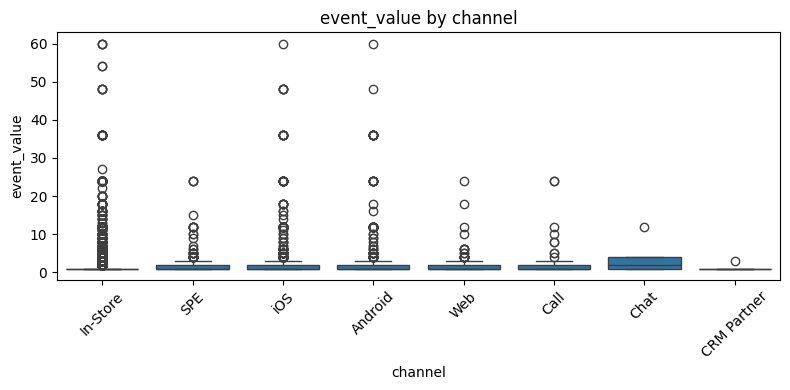


Boxplot: event_value theo payment


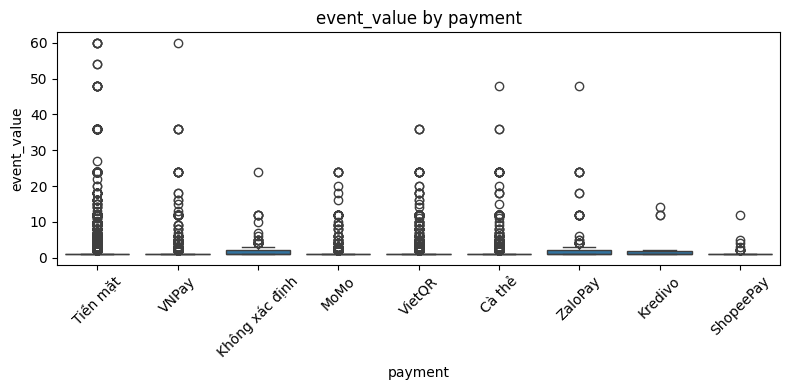


Boxplot: event_value theo is_deleted


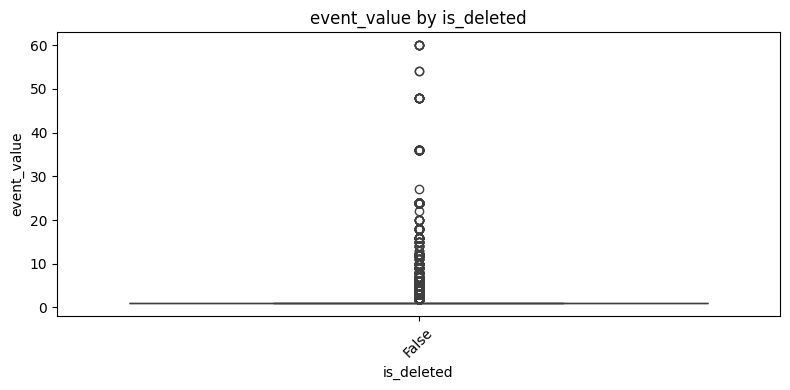


Boxplot: price theo event_type


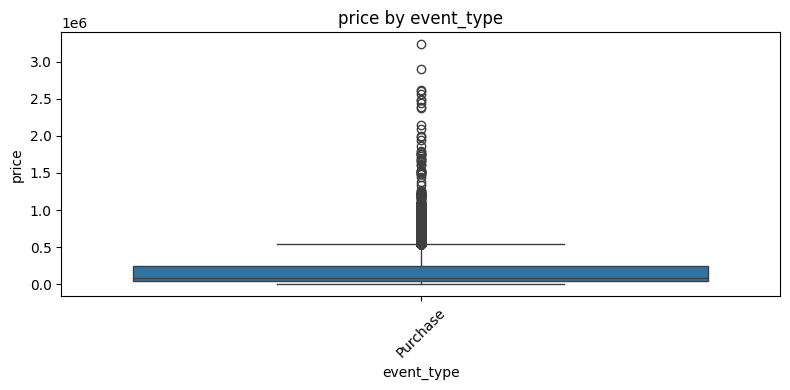


Boxplot: price theo channel


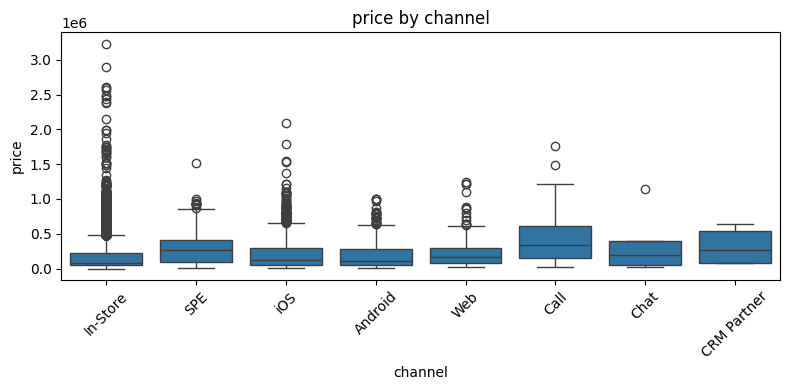


Boxplot: price theo payment


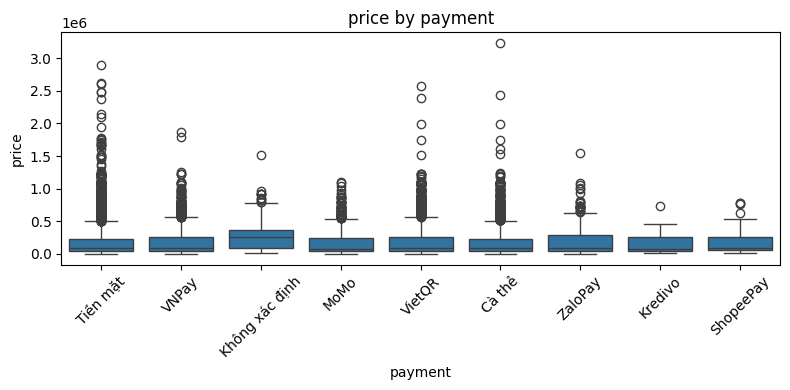


Boxplot: price theo is_deleted


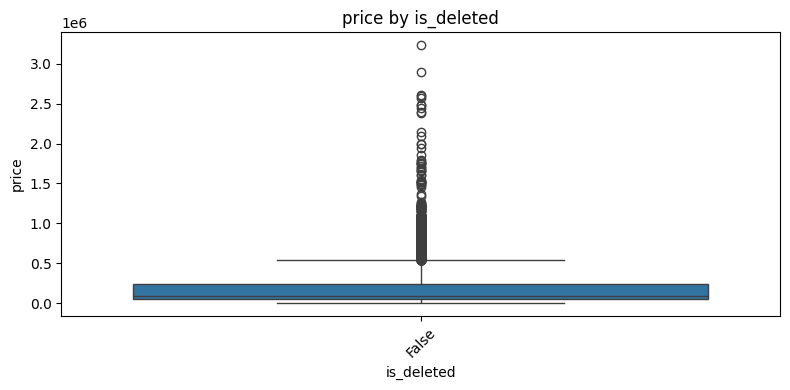


Boxplot: date_key theo event_type


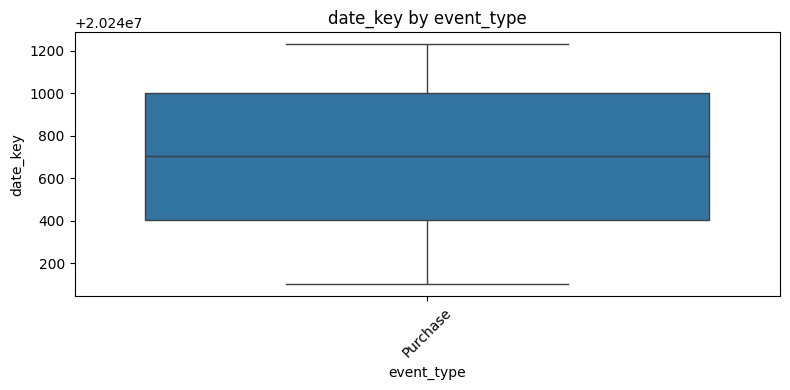


Boxplot: date_key theo channel


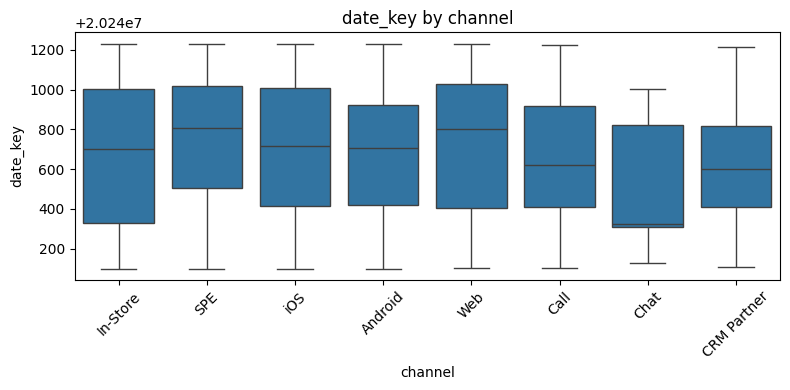


Boxplot: date_key theo payment


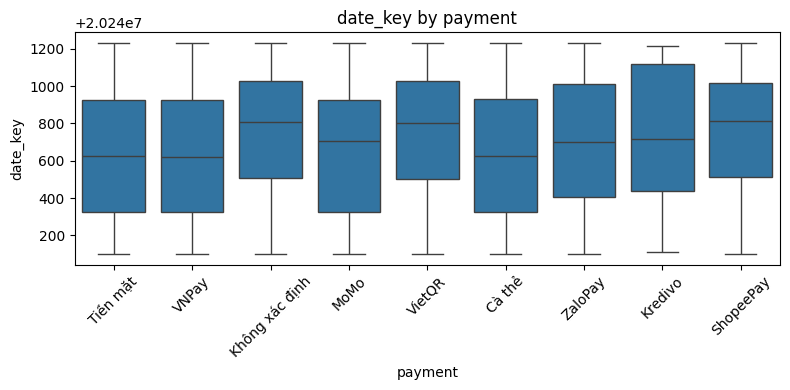


Boxplot: date_key theo is_deleted


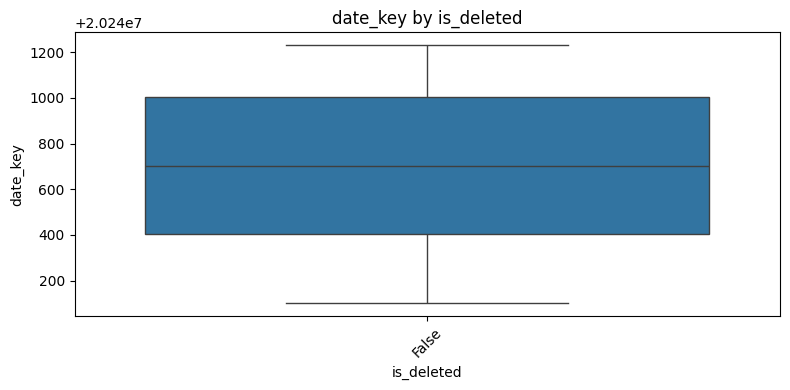


Boxplot: quantity theo event_type


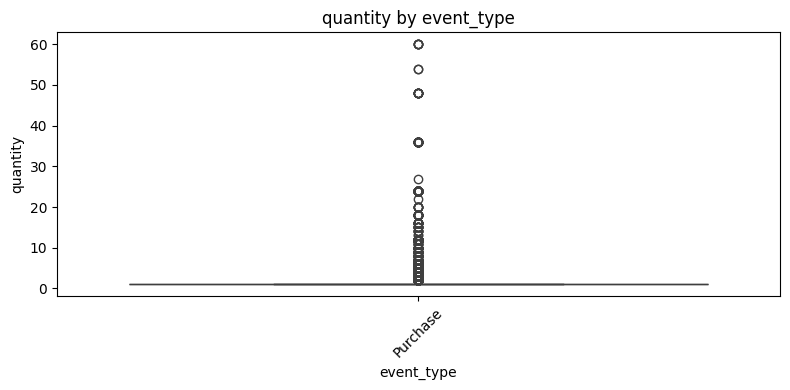


Boxplot: quantity theo channel


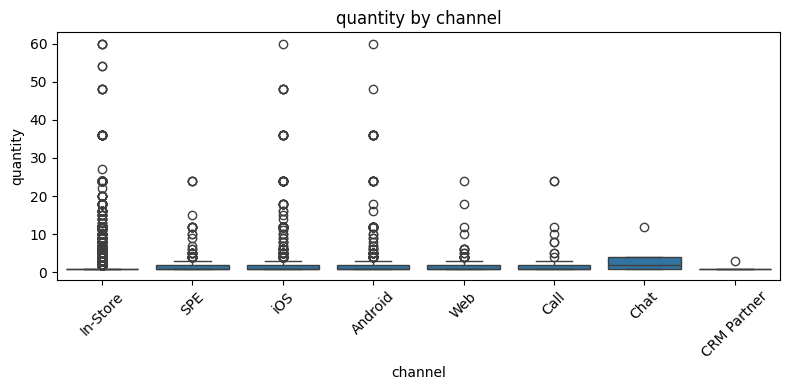


Boxplot: quantity theo payment


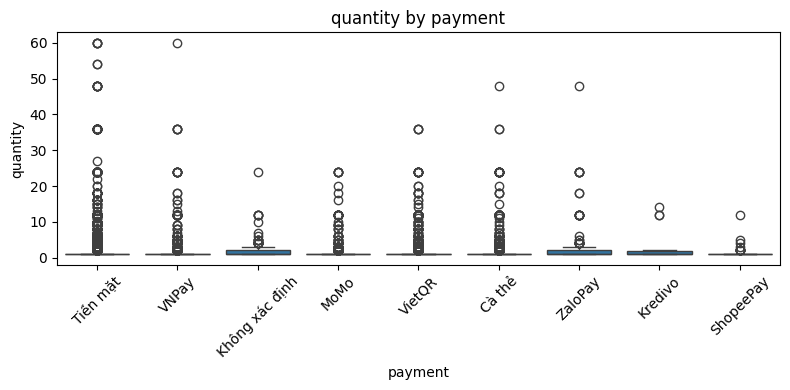


Boxplot: quantity theo is_deleted


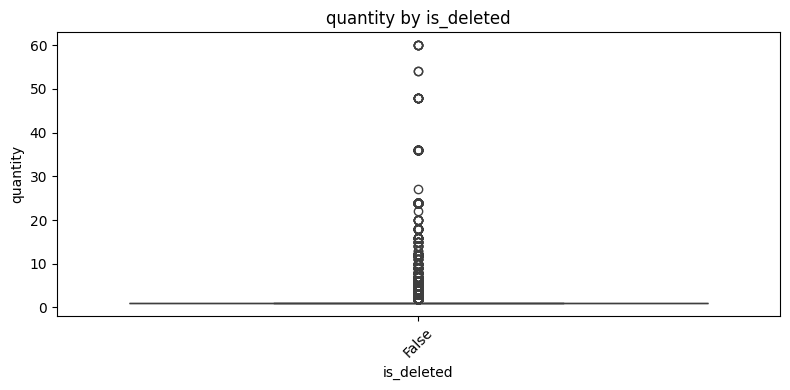


Boxplot: customer_id theo event_type


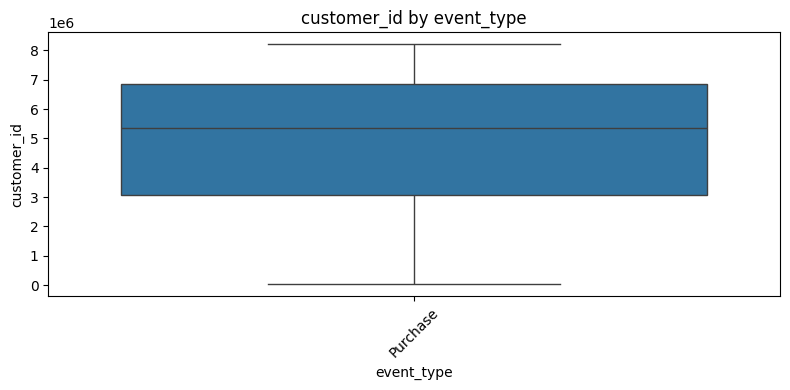


Boxplot: customer_id theo channel


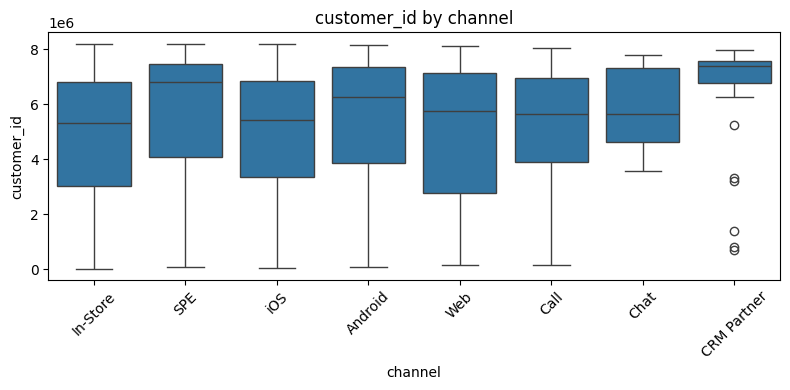


Boxplot: customer_id theo payment


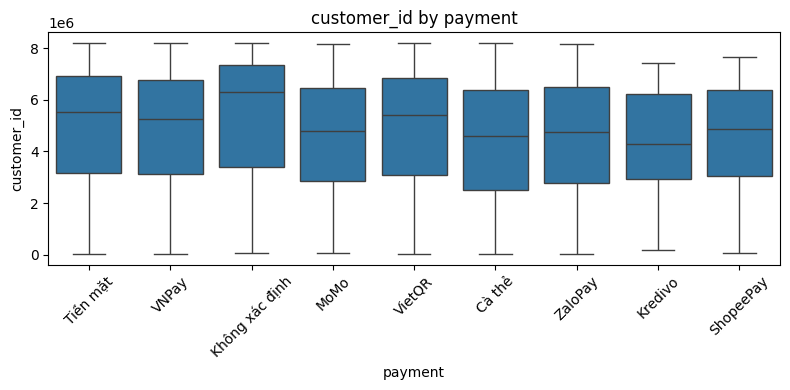


Boxplot: customer_id theo is_deleted


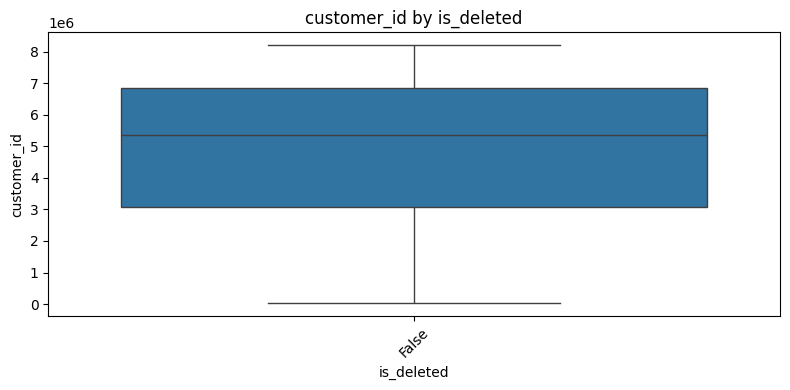


Boxplot: location theo event_type


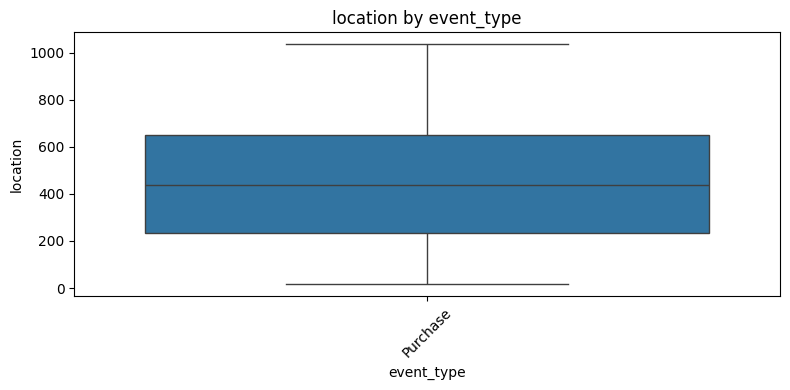


Boxplot: location theo channel


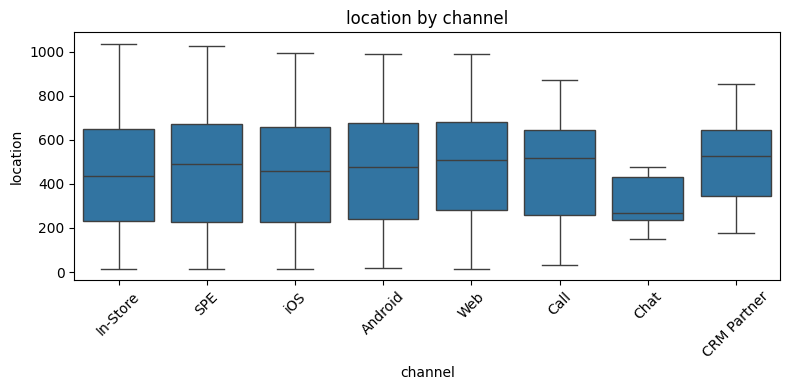


Boxplot: location theo payment


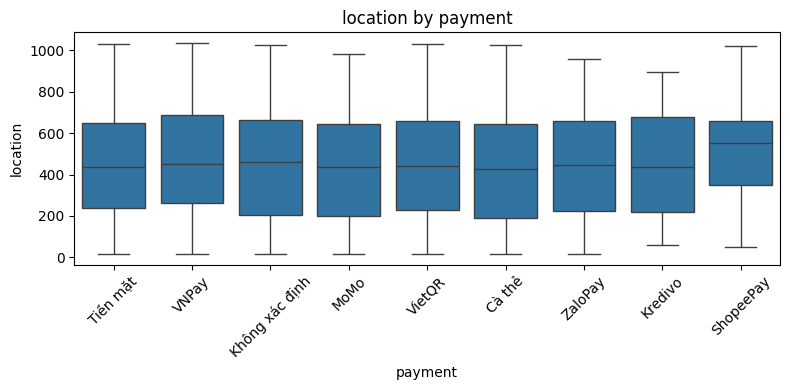


Boxplot: location theo is_deleted


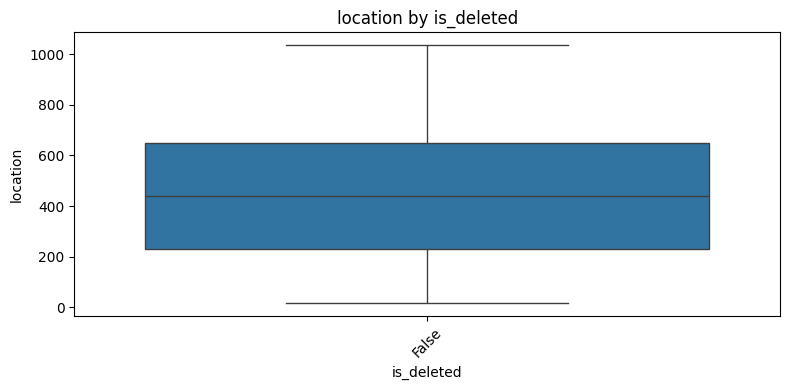


Boxplot: discount theo event_type


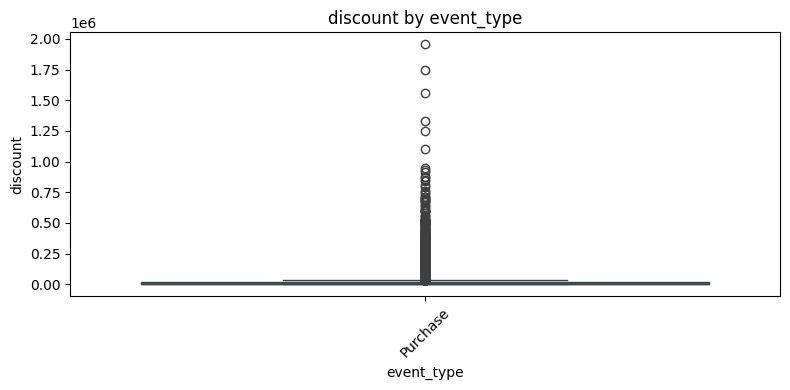


Boxplot: discount theo channel


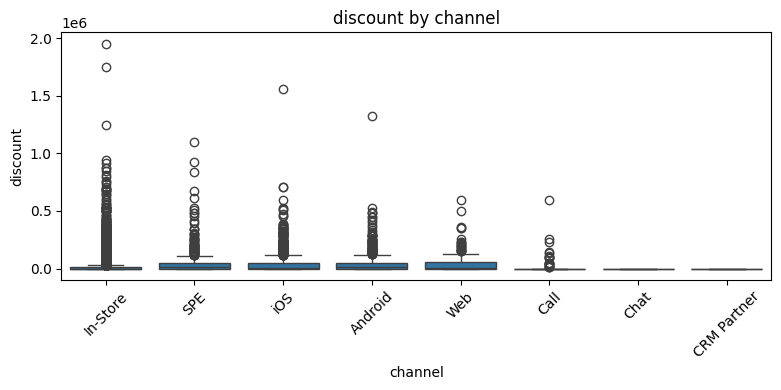


Boxplot: discount theo payment


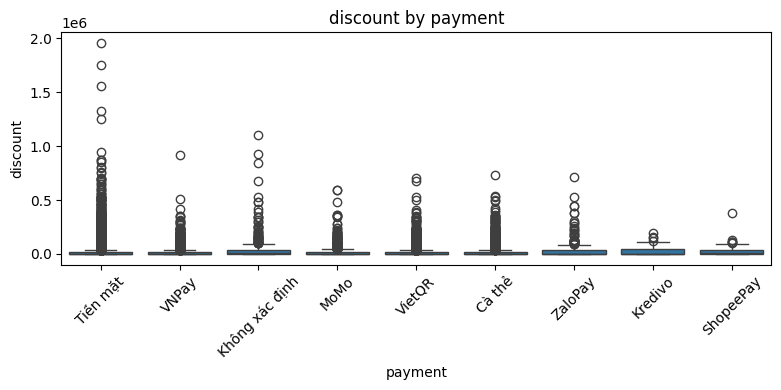


Boxplot: discount theo is_deleted


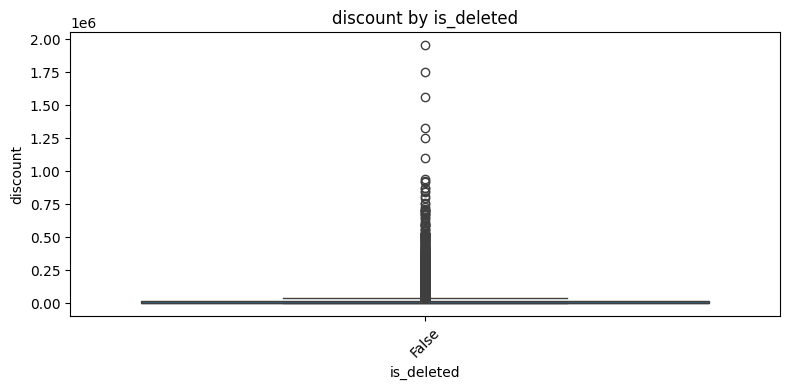


========== HAI BIẾN: CATEGORY – CATEGORY (Cramér's V) (df_purchase_sample) ==========
Các cột categorical dùng để tính Cramér's V (2 ≤ nunique ≤ 50):
['user_id', 'item_id', 'event_type', 'channel', 'payment', 'is_deleted']


NameError: name 'pd' is not defined

In [15]:
# ================================
# 6. CÁCH GỌI CHO df_item
# ================================

# Giả sử bạn đã load dữ liệu vào df_item bằng Polars:
# df_item = pl.read_parquet("user.parquet")   # ví dụ
# hoặc từ CSV:
# df_item = pl.read_csv("user.csv")

# Chạy EDA:
run_eda_for_user(df_purchase_sample)